# Assignment 1

By the deadline, please submit the provided Jupyter notebook with all/some required tasks completed and clearly solved. Make sure your code is neat, well-commented, and that all outputs are visible (run all cells before saving). Notebooks with missing tasks or unexecuted cells may receive fewer points. After you submit, you won’t be able to make changes, so double-check your work and be sure to start from the provided template

## Submission rules
As already discussed in class, we will stick to the following rules.
- Use the templates and name your files `NAME_SURNAME.ipynb` (If you have more than one name, just concatenate them). We will compare what you present with that file. 
- Code either not written in Python or not using PyTorch receives a grade of 0. Of course, you can use auxiliary packages when needed (`matplotlib`, `numpy`, ...), but for the learning part, you must use PyTorch.
-  If plagiarism is suspected, TAs and I will thoroughly investigate the situation, and we will summon the student for a face-to-face clarification regarding certain answers they provided. In case of plagiarism, a score reduction will be applied to all the people involved, depending on their level of involvement.
-  If extensive usage of AI tools is detected, we will summon the student for a face-to-face clarification regarding certain answers they provided. If the answers are not adequately supported with in-person answers, we will proceed to apply a penalty to the evaluation, ranging from 10% to 100%.

## Polynomial regression with gradient descent

Let $z \in \mathbb{R}$ and consider the polynomial
\begin{equation}
    p(z) = \frac{z^4}{100} - \frac{z^3}{10} + 5z^2 -z + 1  = {\sum_{ k = 0}^4 z^k w_k}
\end{equation}
where ${w} = [w_0, w_1, w_2, w_3, w_4]^T = [1, -1, 5, -0.1, \frac{1}{100}]^T$. This polynomial can also be expressed as the dot product of two vectors, namely
$$p(z) = {x}{w}^T \quad {x} = [1, z, z^2, z^3, z^4]$$

Consider an independent and identically distributed (i.i.d.) dataset $\mathcal{D} = \{(z_i, y_i)\}_{i = 1}^N$, where $y_i = p(z_i) + \varepsilon_i$, and each $\varepsilon_i$ is drawn from a normal distribution with mean zero and standard deviation $\sigma$.

Now, assuming that the vector ${w}$ is unknown, linear regression could estimate it using the dot-product form presented in the previous Equation. To achieve this, we can move to another dataset
$$\mathcal{D}' := \{({x}_i, y_i)\}_{i = 1}^N \qquad {x}^i =  [1, z_i, z_i^2, z_i^3, z_i^4]$$

The task of this assignment is to perform polynomial regression using gradient descent with PyTorch.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from numpy.typing import NDArray

### Task 1 (0 pts)
Asses the version of `numpy`, to be sure to read the exact documentation

In [7]:
print(np.version.version)

2.3.3


### Task 1 (5 pts)
Define a function `plot_polynomial(coeffs, z_range, color='b')`, where `coeffs` is a `np.array` containing $[w_0, w_1, w_2, w_3, w_4]^T$,  `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$ of the $z$ variable; `color` represent a color. Use the function to plot the polynomial in the range $[-4, 4]$. Report the plot. In coding this function, you can use `numpy`.

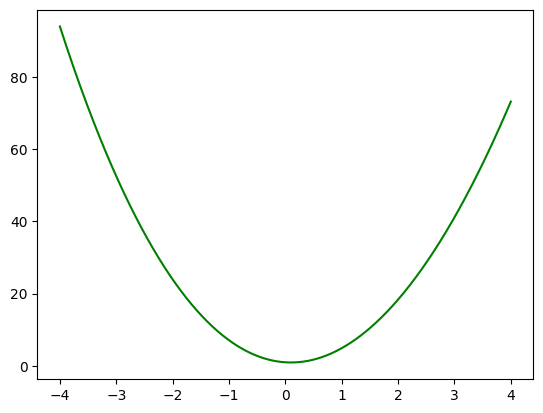

In [8]:
def plot_polynomial(coeffs: NDArray[np.float64], z_range: tuple[int, int], color='b'):
    z_min, z_max = z_range
    # generate z values
    z_values = np.linspace(z_min, z_max, 1000).reshape(-1, 1)
    # compute x_i and matrix multiplicate coeffs on each x_i
    p = (z_values ** np.arange(5)) @ coeffs
    # plot the result
    plt.plot(z_values, p.squeeze(), c=color, label='polynomial')
    

# demonstration
coeffs = np.array([[1, -1, 5, -0.1, 0.01]]).T
z_range = (-4,4)
plot_polynomial(coeffs, z_range, color="green")

### Task 2 (15 pts)
Write a function `create_dataset(coeffs, z_range, sample_size, sigma, seed=42)` that generates the dataset $\mathcal{D'}$.  where `coeffs` is a `np.array` containing $[w_0, w_1, w_2, w_3, w_4]^T$,  `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$ of the $z$ variable; `sample_size` is the dimension of the sample; `sigma` is the standard deviation of the normal distrbution from which $\varepsilon_i$ are sampled; `seed` is the seed for the random procedure. Your function must return two `torch.tensor` with the noisy dataset.

In [9]:
# understand parameter TODO
# Type for train and validation data
type Data = tuple[torch.Tensor, torch.Tensor]
def create_dataset(
    coeffs: NDArray[np.float64],
    z_range: tuple[int, int],
    sample_size=10,
    sigma=0.1,
    seed=42,
) -> Data:
    # Set random state
    torch.manual_seed(seed)
    # Convert coeffs to tensor
    w = torch.from_numpy(coeffs)
    z_min, z_max = z_range
    X = torch.rand(sample_size)
    # Rescale between x_min and x_max
    X = X * (z_max - z_min) + z_min
    # Compute vectors x^i
    X = X.unsqueeze(1) ** torch.arange(w.size(0))
    # Compute p(z)
    p_z = torch.sum(X * w.T, dim=1) # TODO matrix mult
    # Compute y (Add Gaussian noise)
    y = p_z + torch.normal(mean=0.0, std=sigma, size=(sample_size,))
    return X, y

### Task 4 (5pts)

Use the code of the previous point to generate data with the following parameters
- Each $z_i$ should be in the interval $[-2, 2]$
- $\sigma = 0.5$
- Use a sample size of 500 for training data and a seed of 0
- Use a sample size of 500 for evaluation data and a seed of 1

In [10]:
coeffs = np.array([[1, -1, 5, -0.1, 0.01]], dtype=np.float32).T
X_train, y_train = create_dataset(coeffs, (-2,2), sample_size=500, sigma=0.5, seed=0)
X_val, y_val = create_dataset(coeffs, (-2,2), sample_size=500, sigma=0.5, seed=1)

### Task 5 (10 pts)
Define a function `visualize_data(X, y, coeffs, z_range, title="")` that plots the polynomial $p(z)$ and the generated data, (train and validation), where `X, y` are as returned from the function `create_dataset`, `coeffs` are the coefficient of the polynomial, `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$  of the $z$ variable and `title` may be helpful to distinguish between the training and the validation plots. More specifically, provide two plots containing both the true polynomial. In one, add a scatter plot with the training data, and in the other, a scatter plot with the validation data. Use the function to visualize the data.  At this point, you should have noticed that, depending on the circumstances, it is advantageous to store the polynomial coefficients either from the degree 0 term to the degree $n$ term, or vice versa.

In [11]:
def visualize_data(
    X: torch.tensor,
    y: torch.tensor,
    coeffs: NDArray[np.float64],
    z_range: tuple[int, int],
    title="",
):
    if title:
        plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.scatter(X[:,1], y, 20, 'black', alpha=0.5, linewidths=0.5, label='data')
    plot_polynomial(coeffs, z_range, 'red')
    plt.legend(loc='best')
    plt.show()

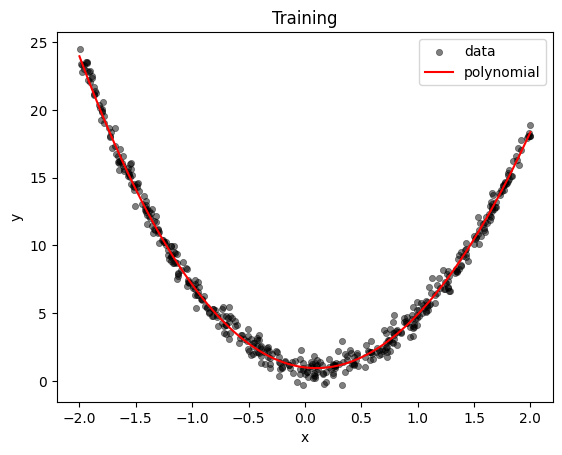

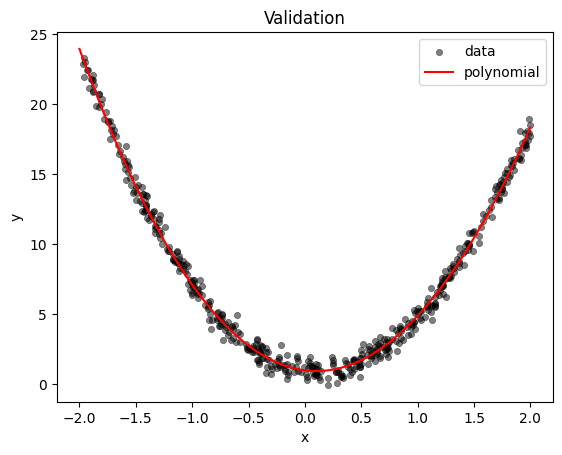

In [12]:
visualize_data(X_train, y_train, coeffs, (-2,2), title="Training")
visualize_data(X_val, y_val, coeffs, (-2,2), title="Validation")

### Task 6 (30 pts)
Perform polynomial regression on $\mathcal{D}$ using linear regression on $\mathcal{D'}$. You will be asked to motivate
- Which learning rate do you use, and why;
- What happens if the learning rate is too small? What happens if the learning rate is too high, and why?
- If `bias` should be set as `True` or `False` in `torch.nn.Linear` and why. 
- How many steps did you use, and why did you retain that  they were enough

You should use the data you generated at Task 4. 

In [13]:
# TODO REMOVE
# compute safe learning rate estimate
import torch
# assume X_train is (N,5) torch tensor on CPU or DEVICE
X = X_train.clone().to('cpu')  # move to cpu if needed
N = X.shape[0]
# compute X^T X
XtX = X.t() @ X  # (5,5)
print(XtX)
# largest eigenvalue (symmetric)
eigvals = torch.linalg.eigvalsh(XtX)  # real, sorted
print(eigvals)
lambda_max = float(eigvals[-1])
lr_max = N / lambda_max   # stability bound for full-batch GD with your MSE loss
print("lambda_max(X^T X) =", lambda_max)
print("approx safe lr < ", lr_max)

tensor([[ 5.0000e+02, -1.0386e+01,  6.8189e+02, -3.0533e+01,  1.6174e+03],
        [-1.0386e+01,  6.8189e+02, -3.0533e+01,  1.6174e+03, -8.6050e+01],
        [ 6.8189e+02, -3.0533e+01,  1.6174e+03, -8.6050e+01,  4.5559e+03],
        [-3.0533e+01,  1.6174e+03, -8.6050e+01,  4.5559e+03, -2.6966e+02],
        [ 1.6174e+03, -8.6050e+01,  4.5559e+03, -2.6966e+02,  1.4014e+04]])
tensor([   43.1110,    95.4841,   378.7351,  5133.9614, 15718.0488])
lambda_max(X^T X) = 15718.048828125
approx safe lr <  0.03181056411437836


In [14]:
# set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(DEVICE)

# reshape data and send to device
X_train = X_train.to(DEVICE)
y_train = y_train.view(-1,1).to(DEVICE)
X_val = X_val.to(DEVICE)
y_val = y_val.view(-1,1).to(DEVICE)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

cpu
X_train shape: torch.Size([500, 5])
X_val shape: torch.Size([500, 5])


In [15]:
def init_model(learning_rate: float) -> tuple[nn.Linear, nn.MSELoss, optim.SGD]:
    # Initialize model, loss function and optimizer
    model = nn.Linear(5, 1, bias=False, device=DEVICE) # Dimension of input: 5, dimension of output: 1
    loss_fn = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    return model, loss_fn, optimizer

In [16]:
steps = 100
def fit(data_train: Data, data_val: Data, learning_rate=0.01, steps=100) -> tuple[nn.Linear, list[float], list[float]]:
    # init model, loss_fn and optimizer
    model, loss_fn, optimizer = init_model(learning_rate)
    
    X_train, y_train = data_train
    X_val, y_val = data_val
    
    train_loss_vals = []
    val_loss_vals = []
    for step in range(steps):
        # Set model to training mode
        model.train()
        # Set gradient to 0
        optimizer.zero_grad()
        # Compute output of model
        p_z = model(X_train)
        # Compute loss
        loss = loss_fn(p_z, y_train)
        # Compute gradient
        loss.backward()
        # Update parameters
        optimizer.step()
        # *** Evaluation ***
        model.eval()
        with torch.no_grad():
            # Compute output of model
            p_z_val = model(X_val)
            # Compute loss
            loss_val = loss_fn(p_z_val, y_val)
            # Save output of model
            val_loss_vals.append(loss_val.item())
            train_loss_vals.append(loss.item())
            if step % 10 == 0:
                print(f"Step: {step} - Loss eval: {loss_val.item()}")

    # Get the final value of the parameters
    print("Final w:", model.weight)
    return model, train_loss_vals, val_loss_vals
    
model, train_loss_vals, val_loss_vals = fit((X_train, y_train), (X_val, y_val))
# TODO Gridsearch

Step: 0 - Loss eval: 24.89483070373535
Step: 10 - Loss eval: 5.723960876464844
Step: 20 - Loss eval: 4.582034587860107
Step: 30 - Loss eval: 3.7241604328155518
Step: 40 - Loss eval: 3.0813164710998535
Step: 50 - Loss eval: 2.597852945327759
Step: 60 - Loss eval: 2.232287645339966
Step: 70 - Loss eval: 1.9539909362792969
Step: 80 - Loss eval: 1.7403723001480103
Step: 90 - Loss eval: 1.5747663974761963
Final w: Parameter containing:
tensor([[ 1.9738, -0.6063,  2.0849, -0.2536,  0.8585]], requires_grad=True)


### Task 7 (10 pts)
Plot the training and validation loss as functions of the iterations and report them in the same plot. If you use both steps and epochs, you can choose either of the two, as long as it is clear from the plot and the plot reports what we expect - namely, that the loss functions decrease.

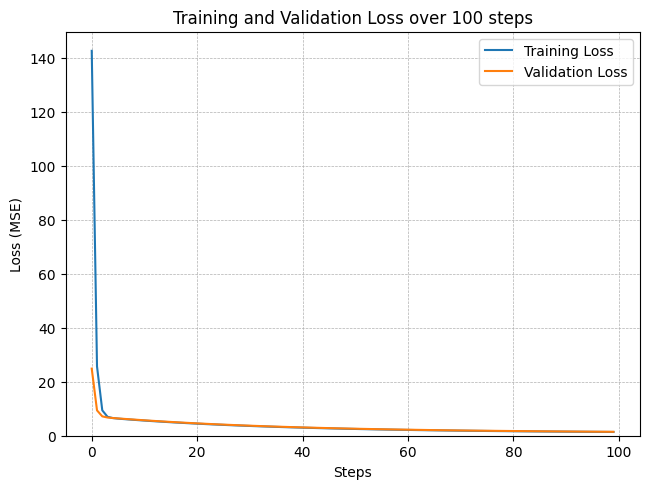

In [17]:
plt.plot(range(len(train_loss_vals)), train_loss_vals, label='Training Loss')
plt.plot(range(len(val_loss_vals)), val_loss_vals, label='Validation Loss')
plt.title(f"Training and Validation Loss over {steps} steps")
plt.legend(loc="best")
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.ylim(bottom=0)
plt.xlabel("Steps")
plt.ylabel("Loss (MSE)")
plt.show()

### Task 8 (10 pts)
Define a function `plot_polynomials(coeffs_list, z_range, color='b')`, where `coeffs_list` is a list containing `np.array`s of type $[w_0, w_1, w_2, w_3, w_4]^T$ of the polynomials you want to plot,  `z_range` is the interval $[z_{\text{min}}, z_{\text{max}}]$ of the $z$ variable; `colors` is a  list of colors, `legend` is a list of labels you want to put. Use the function to plot the polynomial in the range $[-4, 4]$. Report the plot. In coding this function, you can use `numpy`.

In [18]:
def plot_polynomials(coeffs_list, z_range, colors, legend):
    for coeffs, color in zip(coeffs_list, colors):
        plot_polynomial(coeffs, z_range, color)
    plt.legend(legend, loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

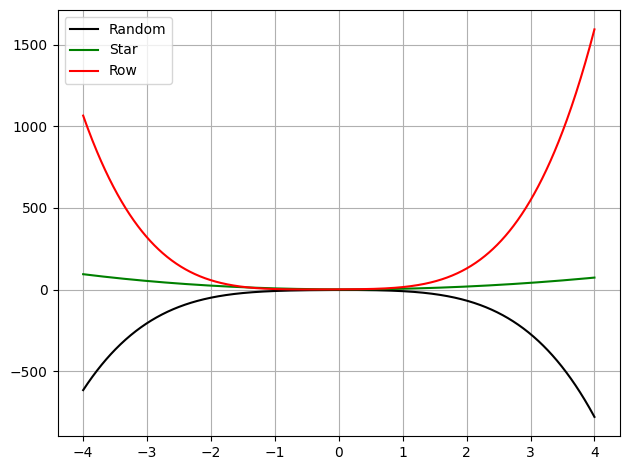

In [19]:
coeffs_list = np.array([np.random.randn(5)*np.random.randint(1,10,1), [1, -1, 5, -0.1, 0.01], [1.,2.,3.,4.,5.]])
# reshape from [z_0,...,z_i] to [z_0.T,...,z_i.T]
coeffs_list = coeffs_list.reshape(3,5,1)
plot_polynomials(coeffs_list, (-4,4), ['black', 'green', 'red'], ["Random","Star","Row"])

### Task 9 (15 points)
Plot the value of the parameters at each iteration, as well as the true value. What we expect is a plot having on the $x$ axis the number of steps/epochs and on the $y$ axis the value of the parameters while they are learned. Then, in the same graph, plot a horizontal line with the true value.

Step: 0 - Loss eval: 18.525087356567383
Step: 10 - Loss eval: 5.535350799560547
Step: 20 - Loss eval: 3.6866323947906494
Step: 30 - Loss eval: 2.6478471755981445
Step: 40 - Loss eval: 2.0492472648620605
Step: 50 - Loss eval: 1.6914703845977783
Step: 60 - Loss eval: 1.4665132761001587
Step: 70 - Loss eval: 1.315764307975769
Step: 80 - Loss eval: 1.2073252201080322
Step: 90 - Loss eval: 1.1237587928771973
Step: 100 - Loss eval: 1.0554620027542114
Step: 110 - Loss eval: 0.997087299823761
Step: 120 - Loss eval: 0.9456014037132263
Step: 130 - Loss eval: 0.8992388844490051
Step: 140 - Loss eval: 0.856931746006012
Step: 150 - Loss eval: 0.8180005550384521
Step: 160 - Loss eval: 0.7819864749908447
Step: 170 - Loss eval: 0.7485583424568176
Step: 180 - Loss eval: 0.7174612879753113
Step: 190 - Loss eval: 0.6884893774986267
Step: 200 - Loss eval: 0.6614687442779541
Step: 210 - Loss eval: 0.6362475156784058
Step: 220 - Loss eval: 0.6126915812492371
Step: 230 - Loss eval: 0.5906798839569092
Step: 2

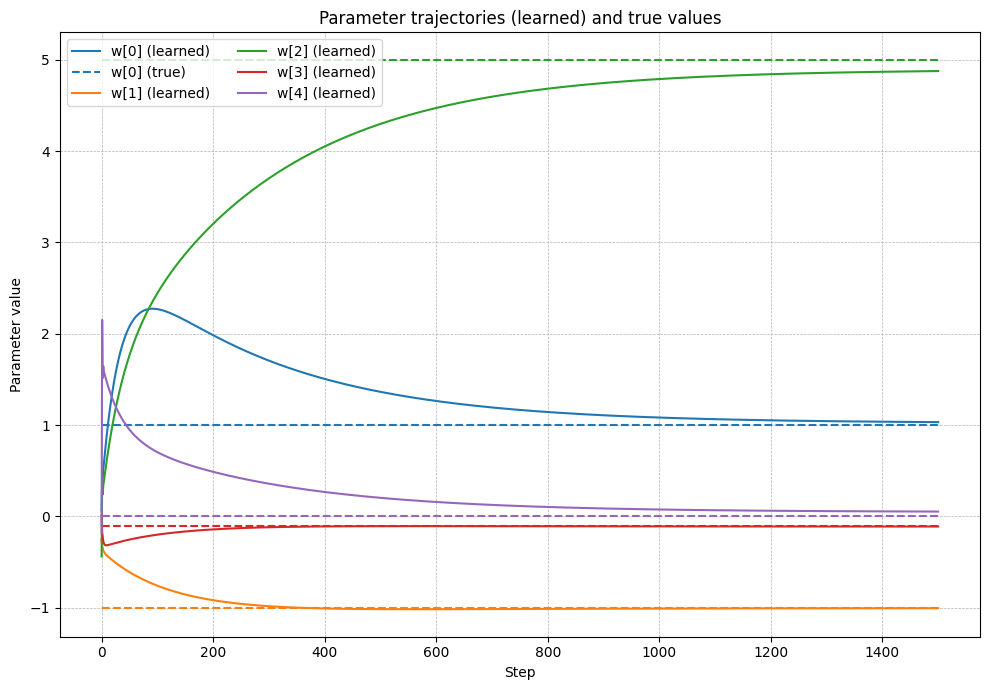

In [22]:
steps = 1500
learning_rate = 0.02

def fit_with_param_hist(
    data_train: Data, data_val: Data, learning_rate=0.01, steps=100
) -> tuple[nn.Linear, list[float], list[float], list[list[float]]]:
    # init model, loss_fn and optimizer
    model, loss_fn, optimizer = init_model(learning_rate)

    X_train, y_train = data_train
    X_val, y_val = data_val

    train_loss_vals = []
    val_loss_vals = []
    params_history = [model.weight.detach().flatten().tolist()]
    for step in range(steps):
        # Set model to training mode
        model.train()
        # Set gradient to 0
        optimizer.zero_grad()
        # Compute output of model
        p_z = model(X_train)
        # Compute loss
        loss = loss_fn(p_z, y_train)
        # Compute gradient
        loss.backward()
        # Update parameters
        optimizer.step()
        # *** Evaluation ***
        model.eval()
        with torch.no_grad():
            params_history.append(model.weight.detach().flatten().tolist())
            # Compute output of model
            p_z_val = model(X_val)
            # Compute loss
            loss_val = loss_fn(p_z_val, y_val)
            # Save output of model
            val_loss_vals.append(loss_val.item())
            train_loss_vals.append(loss.item())
            if step % 10 == 0:
                print(f"Step: {step} - Loss eval: {loss_val.item()}")

    # Get the final value of the parameters
    print("Final w:", model.weight)
    return (
        model,
        train_loss_vals,
        val_loss_vals,
        params_history        
    )


model, train_loss_vals, val_loss_vals, params_history = fit_with_param_hist((X_train, y_train), (X_val, y_val), learning_rate=learning_rate, steps=steps)

w_true = np.array([1, -1, 5, -0.1, 0.01])

steps_idx = range(len(params_history))
plt.figure(figsize=(10,7))
for i in range(len(params_history[0])):
    plt.plot(steps_idx, [params[i] for params in params_history], label=f"w[{i}] (learned)")
    plt.hlines(w_true[i], xmin=0, xmax=steps_idx[-1], colors=f"C{i}", linestyles='--', 
               label=f"w[{i}] (true)" if i==0 else None)  # label true only once

plt.xlabel("Step")
plt.ylabel("Parameter value")
plt.title("Parameter trajectories (learned) and true values")
plt.legend(loc="best", ncol=2)
plt.grid(True, ls="--", lw=0.5)
plt.tight_layout()
plt.show()

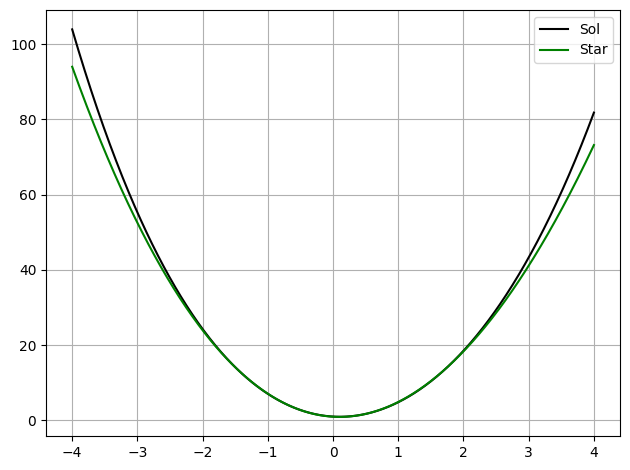

In [23]:
params_history[-1]
coeffs_list = np.array([np.array(params_history[-1]), [1, -1, 5, -0.1, 0.01]])
# reshape from [z_0,...,z_i] to [z_0.T,...,z_i.T]
coeffs_list = coeffs_list.reshape(2,5,1)
plot_polynomials(coeffs_list, (-4,4), ['black', 'green'], ["Sol","Star"])

## Questions

During the presentation, we may ask questions to ensure you have understood the core concepts of the course. Examples include:
- What is the learning rate, and why is it important?
Name a loss function you would use for classification tasks.
-  What are adaptive optimization methods? Can you mention one?
-  What is the difference between steps and epochs?
-  What does the optimizer’s `step()` function do during training?
-  What is a validation set, and why is it used during training?
-  What is overfitting, and how can you reduce it?
-  Why is it necessary to zero out gradients (e.g., `optimizer.zero_grad()`) before the backward pass?

In [16]:
# TODO prepare for questions